In [176]:
import numpy as np
import pandas as pd
import re

In [177]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [102]:
df = pd.read_csv("Gurgaon_Properties_Cleaned_v001.csv")

In [103]:
df.duplicated().sum()

122

In [104]:
df.head(1)
# focus is on -> areaWithType, additionalRoom, agePossession, furnishDetails, features 

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features
0,house,independent,sector 8,0.45,9000.0,500.0,Carpet area: 500 (46.45 sq.m.),1,1,1,not available,3.0,East,undefined,NaN,NaN,NaN


In [105]:
df[['area', 'areaWithType']].sample(5)

,area,areaWithType
424,2450.0,Super Built up area 2690(249.91 sq.m.)Built Up area: 2599 sq.ft. (241.46 sq.m.)Carpet area: 2450 sq.ft. (227.61 sq.m.)
1132,2143.0,Super Built up area 2143(199.09 sq.m.)
2593,990.0,Built Up area: 990 (91.97 sq.m.)
3632,2480.0,Super Built up area 2480(230.4 sq.m.)Built Up area: 2470 sq.ft. (229.47 sq.m.)Carpet area: 2000 sq.ft. (185.81 sq.m.)
303,2408.0,Super Built up area 2408(223.71 sq.m.)Carpet area: 1685 sq.ft. (156.54 sq.m.)


## 1. areaWithType

In [106]:
df.sample(5)[['price','area','areaWithType']]

,price,area,areaWithType
61,2.85,1828.0,Super Built up area 1828(169.83 sq.m.)
1085,0.60,1170.0,Plot area 130(108.7 sq.m.)
2272,0.42,654.0,Super Built up area 623(57.88 sq.m.)
2219,1.98,2191.0,Super Built up area 2191(203.55 sq.m.)
2484,1.50,1350.0,Carpet area: 1350 (125.42 sq.m.)


In [107]:
# This function extracts the Super Built up area
def get_super_built_up_area(text):
    match = re.search(r'Super Built up area (\d+\.?\d*)', text)
    # in super built up area colon is not there
    if match:
        return float(match.group(1))
    return None

In [86]:
# print(get_super_built_up_area("Super Built up area 602(55.93 sq.m.)Carpet area: 548 sq.ft. (50.91 sq.m.)"))

602.0


In [85]:
# print(get_super_built_up_area("Plot area 2700(250.84 sq.m.)Built Up area: 9500 sq.ft. (882.58 sq.m.)Carpet area: 9000 sq.ft. (836.13 sq.m.)"))

None


In [108]:
# This function extracts the Built Up area or Carpet area
def get_area(text, area_type):
    match = re.search(area_type + r'\s*:\s*(\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [91]:
# print(get_area("Super Built up area 602(55.93 sq.m.)Carpet area: 548 sq.ft. (50.91 sq.m.)", "Carpet area"))

548.0


In [96]:
# print(get_area("Plot area 2700(250.84 sq.m.)Built Up area: 9500 sq.ft. (882.58 sq.m.)Carpet area: 9000 sq.ft. (836.13 sq.m.)", "Built Up area"))

9500.0


In [109]:
# This function checks if the area is provided in sq.m. and converts it to sqft if needed
def convert_to_sqft(text, area_value):
    if area_value is None:
        return None
    match = re.search(r'{} \((\d+\.?\d*) sq.m.\)'.format(area_value), text)
    if match:
        sq_m_value = float(match.group(1))
        return sq_m_value * 10.7639  # conversion factor from sq.m. to sqft
    return area_value

In [110]:
# Extract Super Built up area and convert to sqft if needed
df['super_built_up_area'] = df['areaWithType'].apply(get_super_built_up_area)
# extracting the value from the above code
df['super_built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['super_built_up_area']), axis=1)

# Extract Built Up area and convert to sqft if needed
df['built_up_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Built Up area'))
df['built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['built_up_area']), axis=1)

# Extract Carpet area and convert to sqft if needed
df['carpet_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Carpet area'))
df['carpet_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['carpet_area']), axis=1)

In [111]:
df[['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
2278,8.50,house,1600.0,Built Up area: 1600 (148.64 sq.m.),NaN,1600.00,NaN
2017,4.35,house,3222.0,Plot area 358(299.33 sq.m.),NaN,NaN,NaN
1622,1.50,house,3000.0,Built Up area: 3000 (278.71 sq.m.),NaN,3000.00,NaN
3369,0.95,flat,1465.0,Super Built up area 1465(136.1 sq.m.)Built Up area: 1175.97 sq.ft. (109.25 sq.m.)Carpet area: 834.96 sq.ft. (77.57 sq.m.),1465.0,1175.97,834.96
326,1.35,flat,1997.0,Super Built up area 1997(185.53 sq.m.),1997.0,NaN,NaN


In [112]:
df.duplicated().sum()

122

In [113]:
# Out of 3800 flats  only 534 flat where 3 values are available

df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].shape

(534, 7)

In [41]:
# (df['super_built_up_area'].isnull())

# df['super_built_up_area'].isnull()

# Both the code output are same

#### This code will show the Non Null value from the Super Built Area column

In [16]:
# df[~(df['super_built_up_area'].isnull())]

In [114]:
df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].shape

(534, 7)

In [115]:
df[df['areaWithType'].str.contains('Plot')][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].head(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
2,0.80,house,1200.0,Plot area 1200(111.48 sq.m.),NaN,NaN,NaN
11,0.70,house,999.0,Plot area 111(92.81 sq.m.),NaN,NaN,NaN
12,16.00,house,4571.0,Plot area 500(418.06 sq.m.),NaN,NaN,NaN
15,6.00,house,2700.0,Plot area 300(250.84 sq.m.),NaN,NaN,NaN
22,3.75,house,1701.0,Plot area 189(158.03 sq.m.),NaN,NaN,NaN


In [116]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                    18
price_per_sqft           18
area                     18
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                 19
facing                 1105
agePossession             1
nearbyLocations         177
furnishDetails          981
features                635
super_built_up_area    1888
built_up_area          2616
carpet_area            1859
dtype: int64

In [117]:
all_nan_df = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']]

In [118]:
all_nan_df.head()

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
2,0.80,house,1200.0,Plot area 1200(111.48 sq.m.),NaN,NaN,NaN
11,0.70,house,999.0,Plot area 111(92.81 sq.m.),NaN,NaN,NaN
12,16.00,house,4571.0,Plot area 500(418.06 sq.m.),NaN,NaN,NaN
15,6.00,house,2700.0,Plot area 300(250.84 sq.m.),NaN,NaN,NaN
22,3.75,house,1701.0,Plot area 189(158.03 sq.m.),NaN,NaN,NaN


In [119]:
all_nan_index = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].index

In [120]:
# Function to extract plot area from 'areaWithType' column
def extract_plot_area(area_with_type):
    match = re.search(r'Plot area (\d+\.?\d*)', area_with_type)
    return float(match.group(1)) if match else None

In [121]:
# print(extract_plot_area("Plot area 1200(111.48 sq.m.)"))

1200.0


In [122]:

all_nan_df['built_up_area'] = all_nan_df['areaWithType'].apply(extract_plot_area)

# Update the original dataframe
#gurgaon_properties.update(filtered_rows)

In [123]:
all_nan_df

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
2,0.80,house,1200.0,Plot area 1200(111.48 sq.m.),NaN,1200.00,NaN
11,0.70,house,999.0,Plot area 111(92.81 sq.m.),NaN,111.00,NaN
12,16.00,house,4571.0,Plot area 500(418.06 sq.m.),NaN,500.00,NaN
15,6.00,house,2700.0,Plot area 300(250.84 sq.m.),NaN,300.00,NaN
22,3.75,house,1701.0,Plot area 189(158.03 sq.m.),NaN,189.00,NaN
24,4.60,house,2160.0,Plot area 240(200.67 sq.m.),NaN,240.00,NaN
25,4.00,house,1836.0,Plot area 204(170.57 sq.m.),NaN,204.00,NaN
32,5.50,house,1935.0,Plot area 215(179.77 sq.m.),NaN,215.00,NaN
53,0.07,house,277.0,Plot area 33(27.59 sq.m.),NaN,33.00,NaN
54,0.50,house,900.0,Plot area 900(83.61 sq.m.),NaN,900.00,NaN


In [124]:
def convert_scale(row):
    if np.isnan(row['area']) or np.isnan(row['built_up_area']):
        return row['built_up_area']
    else:
        if round(row['area']/row['built_up_area']) == 9.0:
            return row['built_up_area'] * 9
            # convert from yard to sq ft
        elif round(row['area']/row['built_up_area']) == 11.0:
            return row['built_up_area'] * 10.7
            # convert from sqm to sq ft
        else:
            return row['built_up_area']

In [125]:
all_nan_df['built_up_area'] = all_nan_df.apply(convert_scale,axis=1)

In [126]:
all_nan_df

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
2,0.80,house,1200.0,Plot area 1200(111.48 sq.m.),NaN,1200.00,NaN
11,0.70,house,999.0,Plot area 111(92.81 sq.m.),NaN,999.00,NaN
12,16.00,house,4571.0,Plot area 500(418.06 sq.m.),NaN,4500.00,NaN
15,6.00,house,2700.0,Plot area 300(250.84 sq.m.),NaN,2700.00,NaN
22,3.75,house,1701.0,Plot area 189(158.03 sq.m.),NaN,1701.00,NaN
24,4.60,house,2160.0,Plot area 240(200.67 sq.m.),NaN,2160.00,NaN
25,4.00,house,1836.0,Plot area 204(170.57 sq.m.),NaN,1836.00,NaN
32,5.50,house,1935.0,Plot area 215(179.77 sq.m.),NaN,1935.00,NaN
53,0.07,house,277.0,Plot area 33(27.59 sq.m.),NaN,33.00,NaN
54,0.50,house,900.0,Plot area 900(83.61 sq.m.),NaN,900.00,NaN


In [128]:
# update the original dataframe
df.update(all_nan_df)

In [129]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                    18
price_per_sqft           18
area                     18
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                 19
facing                 1105
agePossession             1
nearbyLocations         177
furnishDetails          981
features                635
super_built_up_area    1888
built_up_area          2070
carpet_area            1859
dtype: int64

In [130]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area
0,house,independent,sector 8,0.45,9000.0,500.0,Carpet area: 500 (46.45 sq.m.),1,1,1,not available,3.0,East,undefined,NaN,NaN,NaN,NaN,NaN,500.00
1,flat,avl 36 gurgaon,sector 36a,0.50,8333.0,600.0,Built Up area: 600 (55.74 sq.m.)Carpet area: 500 sq.ft. (46.45 sq.m.),1,1,1,not available,5.0,NaN,undefined,NaN,NaN,NaN,NaN,600.0,500.00
2,house,independent,manesar,0.80,6666.0,1200.0,Plot area 1200(111.48 sq.m.),8,8,2,not available,1.0,NaN,1 to 5 Year Old,"['Amba Clinic', 'Ragave Clinic', 'Sercare Clinic', 'Om Clinic', 'Ram Clinic', 'Kushi Clinic', 'Promla Clinic', 'Shree Balaji Clinic', 'Rathore Imt Hospital', 'Dental Hospital', 'Nidan Hospital and Trauma Centre', 'Sagar Clinic', 'Dr. J. S. Sarkar Clinic', 'Bangali Clinic', 'Yadav Clinic', 'Prakash Hospital', 'Petrol pump Maitri motors', ""Domino's Pizza""]",[],NaN,NaN,1200.0,NaN
3,flat,tulip violet,sector 69,1.68,8358.0,2010.0,Super Built up area 2010(186.74 sq.m.),4,4,2,not available,7.0,North,1 to 5 Year Old,"['Airia Mall Sector 68', 'Southern Peripheral Road', 'Golf Course Extension Rd', 'Imperio School', 'DPG Institute of Technology', 'Ektaa Hospitals', 'Indira Gandhi International Airport', 'Vipul Trade Business Centre', 'Radisson Hotel Gurugram', 'SkyJumper Trampoline Park']","['1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']",2010.0,NaN,NaN
4,flat,godrej nature plus,sector 33 road,1.08,13126.0,823.0,Carpet area: 76.44,2,2,3,not available,8.0,NaN,Jan 2024,"['Signature Global Infinity Mall Sohna', 'Badshahpur Sohna Rd Hwy', 'Gurjar Samrat Jaipal Khatana Marg', 'K. R. Mangalam University', 'Vidya Niketan Sr Sec School', 'Sanjivani Hospital', 'Indira Gandhi Intl Airport', 'Garhi Harsaru Junction']",NaN,NaN,NaN,NaN,76.44


## 2.additionalRoom

In [131]:
df['additionalRoom'].value_counts()

not available                                    1587
servant room                                      705
study room                                        250
others                                            225
pooja room                                        165
study room,servant room                            99
store room                                         99
pooja room,servant room                            82
pooja room,study room,servant room,store room      72
servant room,others                                60
pooja room,study room,servant room                 55
pooja room,study room,servant room,others          54
servant room,pooja room                            38
servant room,store room                            33
study room,others                                  29
pooja room,study room                              22
pooja room,others                                  17
pooja room,store room                              15
pooja room,store room,study 

##### Doing One hot encoding

In [132]:

# additional room
# List of new columns to be created
new_cols = ['study room', 'servant room', 'store room', 'pooja room', 'others']

# Populate the new columns based on the "additionalRoom" column
for col in new_cols:
    df[col] = df['additionalRoom'].str.contains(col).astype(int)

In [133]:
df.sample(5)[['additionalRoom','study room', 'servant room', 'store room', 'pooja room', 'others']]

,additionalRoom,study room,servant room,store room,pooja room,others
508,"servant room,pooja room",0,1,0,1,0
3025,study room,1,0,0,0,0
1397,not available,0,0,0,0,0
3162,"pooja room,servant room",0,1,0,1,0
1258,not available,0,0,0,0,0


In [134]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others
0,house,independent,sector 8,0.45,9000.0,500.0,Carpet area: 500 (46.45 sq.m.),1,1,1,not available,3.0,East,undefined,NaN,NaN,NaN,NaN,NaN,500.00,0,0,0,0,0
1,flat,avl 36 gurgaon,sector 36a,0.50,8333.0,600.0,Built Up area: 600 (55.74 sq.m.)Carpet area: 500 sq.ft. (46.45 sq.m.),1,1,1,not available,5.0,NaN,undefined,NaN,NaN,NaN,NaN,600.0,500.00,0,0,0,0,0
2,house,independent,manesar,0.80,6666.0,1200.0,Plot area 1200(111.48 sq.m.),8,8,2,not available,1.0,NaN,1 to 5 Year Old,"['Amba Clinic', 'Ragave Clinic', 'Sercare Clinic', 'Om Clinic', 'Ram Clinic', 'Kushi Clinic', 'Promla Clinic', 'Shree Balaji Clinic', 'Rathore Imt Hospital', 'Dental Hospital', 'Nidan Hospital and Trauma Centre', 'Sagar Clinic', 'Dr. J. S. Sarkar Clinic', 'Bangali Clinic', 'Yadav Clinic', 'Prakash Hospital', 'Petrol pump Maitri motors', ""Domino's Pizza""]",[],NaN,NaN,1200.0,NaN,0,0,0,0,0
3,flat,tulip violet,sector 69,1.68,8358.0,2010.0,Super Built up area 2010(186.74 sq.m.),4,4,2,not available,7.0,North,1 to 5 Year Old,"['Airia Mall Sector 68', 'Southern Peripheral Road', 'Golf Course Extension Rd', 'Imperio School', 'DPG Institute of Technology', 'Ektaa Hospitals', 'Indira Gandhi International Airport', 'Vipul Trade Business Centre', 'Radisson Hotel Gurugram', 'SkyJumper Trampoline Park']","['1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']",2010.0,NaN,NaN,0,0,0,0,0
4,flat,godrej nature plus,sector 33 road,1.08,13126.0,823.0,Carpet area: 76.44,2,2,3,not available,8.0,NaN,Jan 2024,"['Signature Global Infinity Mall Sohna', 'Badshahpur Sohna Rd Hwy', 'Gurjar Samrat Jaipal Khatana Marg', 'K. R. Mangalam University', 'Vidya Niketan Sr Sec School', 'Sanjivani Hospital', 'Indira Gandhi Intl Airport', 'Garhi Harsaru Junction']",NaN,NaN,NaN,NaN,76.44,0,0,0,0,0


## 3.agePossession

In [135]:
df['agePossession'].value_counts()

1 to 5 Year Old       1676
5 to 10 Year Old       575
0 to 1 Year Old        530
undefined              332
10+ Year Old           310
Under Construction      90
Within 6 months         70
Within 3 months         26
Dec 2023                22
By 2023                 19
By 2024                 17
Dec 2024                16
Mar 2024                14
Jan 2024                 8
Oct 2024                 8
Aug 2023                 7
Dec 2025                 7
Jun 2024                 7
Nov 2023                 5
Jul 2024                 4
Oct 2023                 4
By 2025                  4
Sep 2023                 4
Aug 2024                 4
May 2024                 3
Feb 2024                 3
Nov 2024                 3
Jan 2025                 3
Dec 2026                 2
Jun 2027                 2
Jan 2026                 2
Sep 2025                 2
Jul 2025                 2
Oct 2025                 2
Jul 2027                 2
Aug 2025                 2
By 2027                  2
A

In [136]:
def categorize_age_possession(value):
    if pd.isna(value):
        return "Undefined"
    if "0 to 1 Year Old" in value or "Within 6 months" in value or "Within 3 months" in value:
        return "New Property"
    if "1 to 5 Year Old" in value:
        return "Relatively New"
    if "5 to 10 Year Old" in value:
        return "Moderately Old"
    if "10+ Year Old" in value:
        return "Old Property"
    if "Under Construction" in value or "By" in value:
        return "Under Construction"
    try:
        # For entries like 'May 2024'
        int(value.split(" ")[-1])
        return "Under Construction"
    except:
        return "Undefined"

In [137]:
df['agePossession'] = df['agePossession'].apply(categorize_age_possession)

In [138]:
df['agePossession'].value_counts()

Relatively New        1676
New Property           626
Moderately Old         575
Undefined              333
Old Property           310
Under Construction     283
Name: agePossession, dtype: int64

In [139]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others
0,house,independent,sector 8,0.45,9000.0,500.0,Carpet area: 500 (46.45 sq.m.),1,1,1,not available,3.0,East,Undefined,NaN,NaN,NaN,NaN,NaN,500.00,0,0,0,0,0
1,flat,avl 36 gurgaon,sector 36a,0.50,8333.0,600.0,Built Up area: 600 (55.74 sq.m.)Carpet area: 500 sq.ft. (46.45 sq.m.),1,1,1,not available,5.0,NaN,Undefined,NaN,NaN,NaN,NaN,600.0,500.00,0,0,0,0,0
2,house,independent,manesar,0.80,6666.0,1200.0,Plot area 1200(111.48 sq.m.),8,8,2,not available,1.0,NaN,Relatively New,"['Amba Clinic', 'Ragave Clinic', 'Sercare Clinic', 'Om Clinic', 'Ram Clinic', 'Kushi Clinic', 'Promla Clinic', 'Shree Balaji Clinic', 'Rathore Imt Hospital', 'Dental Hospital', 'Nidan Hospital and Trauma Centre', 'Sagar Clinic', 'Dr. J. S. Sarkar Clinic', 'Bangali Clinic', 'Yadav Clinic', 'Prakash Hospital', 'Petrol pump Maitri motors', ""Domino's Pizza""]",[],NaN,NaN,1200.0,NaN,0,0,0,0,0
3,flat,tulip violet,sector 69,1.68,8358.0,2010.0,Super Built up area 2010(186.74 sq.m.),4,4,2,not available,7.0,North,Relatively New,"['Airia Mall Sector 68', 'Southern Peripheral Road', 'Golf Course Extension Rd', 'Imperio School', 'DPG Institute of Technology', 'Ektaa Hospitals', 'Indira Gandhi International Airport', 'Vipul Trade Business Centre', 'Radisson Hotel Gurugram', 'SkyJumper Trampoline Park']","['1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']",2010.0,NaN,NaN,0,0,0,0,0
4,flat,godrej nature plus,sector 33 road,1.08,13126.0,823.0,Carpet area: 76.44,2,2,3,not available,8.0,NaN,Under Construction,"['Signature Global Infinity Mall Sohna', 'Badshahpur Sohna Rd Hwy', 'Gurjar Samrat Jaipal Khatana Marg', 'K. R. Mangalam University', 'Vidya Niketan Sr Sec School', 'Sanjivani Hospital', 'Indira Gandhi Intl Airport', 'Garhi Harsaru Junction']",NaN,NaN,NaN,NaN,76.44,0,0,0,0,0


## 4.furnishDetails

In [140]:
df.sample(5)[['furnishDetails','features']]

,furnishDetails,features
1148,NaN,"['Power Back-up', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'Separate entry for servant room', 'No open drainage around', 'Visitor Parking', 'Swimming Pool', 'Park', 'Internet/wi-fi connectivity', 'Fitness Centre / GYM', 'Club house / Community Center', 'Water softening plant']"
1610,"['1 Fan', '1 Exhaust Fan', '1 Light', '1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking', 'Shopping Centre']"
3231,"['1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",NaN
911,"['1 Exhaust Fan', '3 AC', '1 Modular Kitchen', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Centrally Air Conditioned', 'Water purifier', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'Recently Renovated', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Spacious Interiors', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center']"
445,NaN,"['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Lift(s)', 'Park', 'Visitor Parking']"


In [141]:
# Extract all unique furnishings from the furnishDetails column
all_furnishings = []
for detail in df['furnishDetails'].dropna():
    furnishings = detail.replace('[', '').replace(']', '').replace("'", "").split(', ')
    all_furnishings.extend(furnishings)
unique_furnishings = list(set(all_furnishings))

# Define a function to extract the count of a furnishing from the furnishDetails
def get_furnishing_count(details, furnishing):
    if isinstance(details, str):
        if f"No {furnishing}" in details:
            return 0
        pattern = re.compile(f"(\d+) {furnishing}")
        match = pattern.search(details)
        if match:
            return int(match.group(1))
        elif furnishing in details:
            return 1
    return 0

# Simplify the furnishings list by removing "No" prefix and numbers
columns_to_include = [re.sub(r'No |\d+', '', furnishing).strip() for furnishing in unique_furnishings]
columns_to_include = list(set(columns_to_include))  # Get unique furnishings
columns_to_include = [furnishing for furnishing in columns_to_include if furnishing]  # Remove empty strings

# Create new columns for each unique furnishing and populate with counts
for furnishing in columns_to_include:
    df[furnishing] = df['furnishDetails'].apply(lambda x: get_furnishing_count(x, furnishing))

# Create the new dataframe with the required columns
furnishings_df = df[['furnishDetails'] + columns_to_include]

In [142]:
furnishings_df.shape

(3803, 19)

In [143]:
furnishings_df.drop(columns=['furnishDetails'],inplace=True)

C:\Users\USER\anaconda3\envs\data_env_old\lib\site-packages\pandas\core\frame.py:4906: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().drop(


In [144]:
furnishings_df.sample(5)

,Light,TV,Exhaust Fan,Geyser,Fan,Curtains,Water Purifier,AC,Bed,Wardrobe,Chimney,Modular Kitchen,Dining Table,Sofa,Washing Machine,Microwave,Fridge,Stove
1892,0,0,1,0,0,0,0,6,0,0,0,0,0,0,0,0,0,0
2470,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0
3352,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2927,21,0,1,5,15,0,0,6,0,5,1,1,0,0,0,0,0,0
10,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [145]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [146]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(furnishings_df)

In [147]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss_reduced.append(kmeans.inertia_)

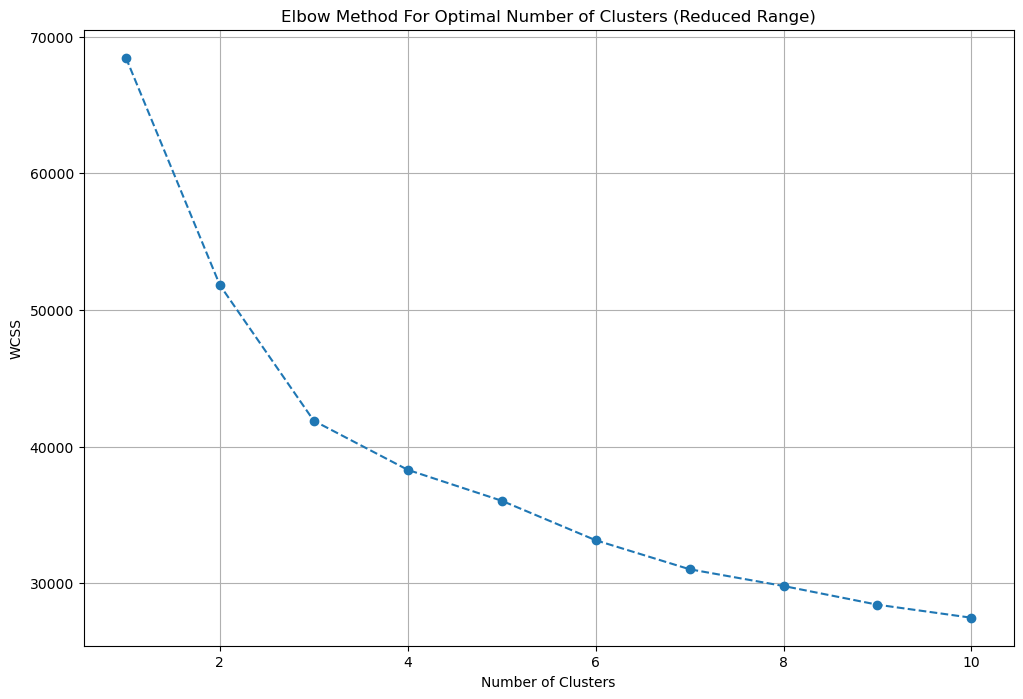

In [148]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

slope reduction rate is reduced from point 3

In [149]:
n_clusters = 3

# Fit the KMeans model
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(scaled_data)

# Predict the cluster assignments for each row
cluster_assignments = kmeans.predict(scaled_data)

In [150]:
df = df.iloc[:,:-18]

In [151]:
df['furnishing_type'] = cluster_assignments

In [152]:
df.sample(5)[['furnishDetails','furnishing_type']]
# 0 -> unfurnished
# 1 -> semifurnished
# 2 -> furnished

,furnishDetails,furnishing_type
465,NaN,1
2902,"['3 Wardrobe', '6 Fan', '3 Geyser', '15 Light', '5 AC', '1 Modular Kitchen', '1 Chimney', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",0
3736,"['2 Wardrobe', '3 Fan', '1 Exhaust Fan', '3 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",1
1253,"['1 Exhaust Fan', '1 Stove', '5 AC', '1 Modular Kitchen', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",0
2044,[],1


## 5.features

In [153]:
df[['society','features']].sample(5)

,society,features
823,dlf carlton estate,"['Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Swimming Pool', 'Park', 'Piped-gas', 'Security Personnel', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center', 'Rain Water Harvesting']"
2649,vipul tatvam villa,"['Private Garden / Terrace', 'Maintenance Staff', 'Piped-gas', 'Visitor Parking', 'Airy Rooms', 'Club house / Community Center']"
714,bestech park view residency,"['Security / Fire Alarm', 'Power Back-up', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']"
3616,pyramid urban,"['Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']"
1288,sare crescent parc royal greens phase 1,NaN


In [51]:
df['features'].isnull().sum()

635

In [154]:
import pandas as pd
app_df = pd.read_csv('appartments.csv')
app_df.head(2)

,PropertyName,PropertySubName,NearbyLocations,LocationAdvantages,Link,PriceDetails,TopFacilities
0,Smartworld One DXP,"2, 3, 4 BHK Apartment in Sector 113, Gurgaon","['Bajghera Road', 'Palam Vihar Halt', 'DPSG Palam Vihar', 'Park Hospital', 'Gurgaon Railway Station']","{'Bajghera Road': '800 Meter', 'Palam Vihar Halt': '2.5 KM', 'DPSG Palam Vihar': '3.1 KM', 'Park Hospital': '3.1 KM', 'Gurgaon Railway Station': '4.9 KM', 'The NorthCap University': '5.4 KM', 'Dwarka Expy': '1.2 KM', 'Hyatt Place Gurgaon Udyog Vihar': '7.7 KM', 'Dwarka Sector 21, Metro Station': '7.2 KM', 'Pacific D21 Mall': '7.4 KM', 'Indira Gandhi International Airport': '14.7 KM', 'Hamoni Golf Camp': '6.2 KM', 'Fun N Food Waterpark': '8.8 KM', 'Accenture DDC5': '9 KM'}",https://www.99acres.com/smartworld-one-dxp-sector-113-gurgaon-npxid-r400415,"{'2 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,370 sq.ft.', 'price-range': '₹ 2 - 2.4 Cr'}, '3 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,850 - 2,050 sq.ft.', 'price-range': '₹ 2.25 - 3.59 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '2,600 sq.ft.', 'price-range': '₹ 3.24 - 4.56 Cr'}}","['Swimming Pool', 'Salon', 'Restaurant', 'Spa', 'Cafeteria', 'Sun Deck', '24x7 Security', 'Club House', 'Gated Community']"
1,M3M Crown,"3, 4 BHK Apartment in Sector 111, Gurgaon","['DPSG Palam Vihar Gurugram', 'The NorthCap University', 'Park Hospital, Palam Vihar', 'Pacific D21 Mall', 'Palam Vihar Halt Railway Station']","{'DPSG Palam Vihar Gurugram': '1.4 Km', 'The NorthCap University': '4.4 Km', 'Park Hospital, Palam Vihar': '1.4 Km', 'Pacific D21 Mall': '8.2 Km', 'Palam Vihar Halt Railway Station': '1.2 Km', 'Dwarka Sector 21 Metro Station': '8.1 Km', 'Dwarka Expressway': '450 m', 'Fun N Food Water Park': '8.1 Km', 'Indira Gandhi International Airport': '14.1 Km', 'Tau DeviLal Sports Complex': '11.2 Km', 'Hamoni Golf Camp': '5 Km', 'Hyatt Place': '6.1 Km', 'Altrade Business Centre': '11.2 Km'}",https://www.99acres.com/m3m-crown-sector-111-gurgaon-npxid-r404068,"{'3 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '1,605 - 2,170 sq.ft.', 'price-range': '₹ 2.2 - 3.03 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '2,248 - 2,670 sq.ft.', 'price-range': '₹ 3.08 - 3.73 Cr'}}","['Bowling Alley', 'Mini Theatre', 'Manicured Garden', 'Swimming Pool', 'Flower Garden', 'Reading Lounge', 'Golf Course', 'Barbecue', 'Sauna']"


In [155]:
app_df['PropertyName'] = app_df['PropertyName'].str.lower()

In [156]:
temp_df = df[df['features'].isnull()]

In [157]:
temp_df.shape

(635, 26)

In [158]:
x = temp_df.merge(app_df,left_on='society',right_on='PropertyName',how='left')['TopFacilities']

# how = left ie left join

In [120]:
# df[df['features'].isnull()]

In [159]:
df.loc[temp_df.index,'features'] = x.values

In [124]:
# df.loc[df['features'].isnull(), 'features']

In [160]:
df['features'].isnull().sum()

481

In [161]:
from sklearn.preprocessing import MultiLabelBinarizer
import ast

In [162]:

# Convert the string representation of lists in the 'features' column to actual lists
df['features_list'] = df['features'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and x.startswith('[') else [])

# Use MultiLabelBinarizer to convert the features list into a binary matrix
mlb = MultiLabelBinarizer()
features_binary_matrix = mlb.fit_transform(df['features_list'])

# Convert the binary matrix into a DataFrame
features_binary_df = pd.DataFrame(features_binary_matrix, columns=mlb.classes_)

In [163]:
features_binary_df.sample(5)

,24/7 Power Backup,24/7 Water Supply,24x7 Security,ATM,Aerobics Centre,Air Hockey,Airy Rooms,Amphitheatre,Automated Car Wash,Badminton Court,Bank Attached Property,Banquet Hall,Bar/Chill-Out Lounge,Barbecue,Basketball Court,Beach Volley Ball Court,Billiards,Bowling Alley,Bus Shelter,Business Lounge,CCTV Camera Security,Cafeteria,Car Parking,Car wash area,Card Room,Centrally Air Conditioned,Changing Area,Children's Play Area,Cigar Lounge,Clinic,Club House,Club house / Community Center,Community Hall,Concierge Service,Conference room,Creche/Day care,Cricket Pitch,Doctor on Call,Earthquake Resistant,Entrance Lobby,False Ceiling Lighting,Feng Shui / Vaastu Compliant,Fire Fighting Systems,Fitness Centre / GYM,Flower Garden,Food Court,Foosball,Football,Fountain,Gated Community,Gazebo,Golf Course,Grocery Shop,Gymnasium,High Ceiling Height,High Speed Elevators,Infinity Pool,Intercom Facility,Internal Street Lights,Internet/wi-fi connectivity,Jacuzzi,Jogging Track,Landscape Garden,Laundry,Lawn Tennis Court,Library,Lift(s),Lounge,Low Density Society,Maintenance Staff,Manicured Garden,Medical Centre,Milk Booth,Mini Theatre,Multipurpose Court,Multipurpose Hall,Natural Light,Natural Pond,No open drainage around,Park,Party Lawn,Pergola,Piped Gas,Piped-gas,Pool Table,Power Back up Lift,Power Back-up,Private Garden / Terrace,Property Staff,RO System,Rain Water Harvesting,Reading Lounge,Recently Renovated,Reflexology Park,Restaurant,Salon,Sauna,School,Security / Fire Alarm,Security Personnel,Separate entry for servant room,Sewage Treatment Plant,Shopping Centre,Skating Rink,Solar Lighting,Solar Water Heating,Spa,Spacious Interiors,Squash Court,Steam Room,Sun Deck,Swimming Pool,Temple,Terrace Garden,Theatre,Toddler Pool,Valet Parking,Vastu Compliant,Video Door Security,Visitor Parking,Visitors Parking,Volley Ball Court,Waiting Lounge,Waste Disposal,Water Softener Plant,Water Storage,Water purifier,Water softening plant,Wi-Fi Connectivity,Yoga/Meditation Area
684,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2691,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0
3600,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
360,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,1,0,0
1357,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [164]:
features_binary_df.shape

(3803, 130)

In [165]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(features_binary_df)
    wcss_reduced.append(kmeans.inertia_)

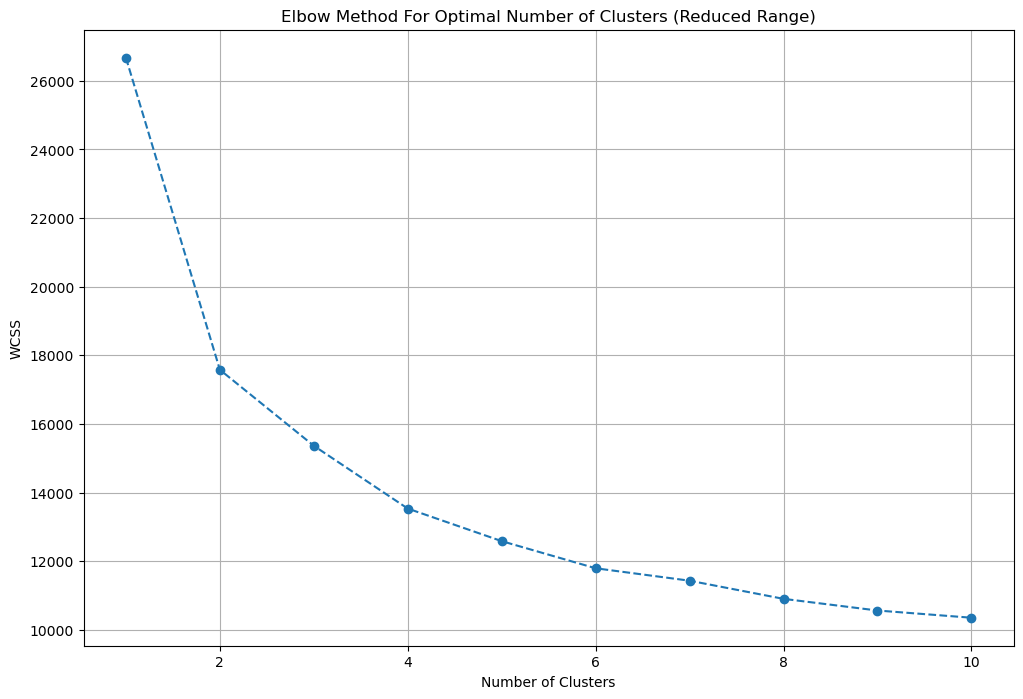

In [166]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [174]:
# Define the weights for each feature as provided
# Assigning weights based on perceived luxury contribution
weights = {
    '24/7 Power Backup': 8,
    '24/7 Water Supply': 4,
    '24x7 Security': 7,
    'ATM': 4,
    'Aerobics Centre': 6,
    'Airy Rooms': 8,
    'Amphitheatre': 7,
    'Badminton Court': 7,
    'Banquet Hall': 8,
    'Bar/Chill-Out Lounge': 9,
    'Barbecue': 7,
    'Basketball Court': 7,
    'Billiards': 7,
    'Bowling Alley': 8,
    'Business Lounge': 9,
    'CCTV Camera Security': 8,
    'Cafeteria': 6,
    'Car Parking': 6,
    'Card Room': 6,
    'Centrally Air Conditioned': 9,
    'Changing Area': 6,
    "Children's Play Area": 7,
    'Cigar Lounge': 9,
    'Clinic': 5,
    'Club House': 9,
    'Concierge Service': 9,
    'Conference room': 8,
    'Creche/Day care': 7,
    'Cricket Pitch': 7,
    'Doctor on Call': 6,
    'Earthquake Resistant': 5,
    'Entrance Lobby': 7,
    'False Ceiling Lighting': 6,
    'Feng Shui / Vaastu Compliant': 5,
    'Fire Fighting Systems': 8,
    'Fitness Centre / GYM': 8,
    'Flower Garden': 7,
    'Food Court': 6,
    'Foosball': 5,
    'Football': 7,
    'Fountain': 7,
    'Gated Community': 7,
    'Golf Course': 10,
    'Grocery Shop': 6,
    'Gymnasium': 8,
    'High Ceiling Height': 8,
    'High Speed Elevators': 8,
    'Infinity Pool': 9,
    'Intercom Facility': 7,
    'Internal Street Lights': 6,
    'Internet/wi-fi connectivity': 7,
    'Jacuzzi': 9,
    'Jogging Track': 7,
    'Landscape Garden': 8,
    'Laundry': 6,
    'Lawn Tennis Court': 8,
    'Library': 8,
    'Lounge': 8,
    'Low Density Society': 7,
    'Maintenance Staff': 6,
    'Manicured Garden': 7,
    'Medical Centre': 5,
    'Milk Booth': 4,
    'Mini Theatre': 9,
    'Multipurpose Court': 7,
    'Multipurpose Hall': 7,
    'Natural Light': 8,
    'Natural Pond': 7,
    'Park': 8,
    'Party Lawn': 8,
    'Piped Gas': 7,
    'Pool Table': 7,
    'Power Back up Lift': 8,
    'Private Garden / Terrace': 9,
    'Property Staff': 7,
    'RO System': 7,
    'Rain Water Harvesting': 7,
    'Reading Lounge': 8,
    'Restaurant': 8,
    'Salon': 8,
    'Sauna': 9,
    'Security / Fire Alarm': 9,
    'Security Personnel': 9,
    'Separate entry for servant room': 8,
    'Sewage Treatment Plant': 6,
    'Shopping Centre': 7,
    'Skating Rink': 7,
    'Solar Lighting': 6,
    'Solar Water Heating': 7,
    'Spa': 9,
    'Spacious Interiors': 9,
    'Squash Court': 8,
    'Steam Room': 9,
    'Sun Deck': 8,
    'Swimming Pool': 8,
    'Temple': 5,
    'Theatre': 9,
    'Toddler Pool': 7,
    'Valet Parking': 9,
    'Video Door Security': 9,
    'Visitor Parking': 7,
    'Water Softener Plant': 7,
    'Water Storage': 7,
    'Water purifier': 7,
    'Yoga/Meditation Area': 7
}
# Calculate luxury score for each row
luxury_score = features_binary_df[list(weights.keys())].multiply(list(weights.values())).sum(axis=1)

In [76]:
# features_binary_df[list(weights.keys())]

In [168]:
df['luxury_score'] = luxury_score

In [169]:

df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,features_list,luxury_score
0,house,independent,sector 8,0.45,9000.0,500.0,Carpet area: 500 (46.45 sq.m.),1,1,1,not available,3.0,East,Undefined,NaN,NaN,NaN,NaN,NaN,500.00,0,0,0,0,0,1,[],0
1,flat,avl 36 gurgaon,sector 36a,0.50,8333.0,600.0,Built Up area: 600 (55.74 sq.m.)Carpet area: 500 sq.ft. (46.45 sq.m.),1,1,1,not available,5.0,NaN,Undefined,NaN,NaN,NaN,NaN,600.0,500.00,0,0,0,0,0,1,[],0
2,house,independent,manesar,0.80,6666.0,1200.0,Plot area 1200(111.48 sq.m.),8,8,2,not available,1.0,NaN,Relatively New,"['Amba Clinic', 'Ragave Clinic', 'Sercare Clinic', 'Om Clinic', 'Ram Clinic', 'Kushi Clinic', 'Promla Clinic', 'Shree Balaji Clinic', 'Rathore Imt Hospital', 'Dental Hospital', 'Nidan Hospital and Trauma Centre', 'Sagar Clinic', 'Dr. J. S. Sarkar Clinic', 'Bangali Clinic', 'Yadav Clinic', 'Prakash Hospital', 'Petrol pump Maitri motors', ""Domino's Pizza""]",[],NaN,NaN,1200.0,NaN,0,0,0,0,0,1,[],0
3,flat,tulip violet,sector 69,1.68,8358.0,2010.0,Super Built up area 2010(186.74 sq.m.),4,4,2,not available,7.0,North,Relatively New,"['Airia Mall Sector 68', 'Southern Peripheral Road', 'Golf Course Extension Rd', 'Imperio School', 'DPG Institute of Technology', 'Ektaa Hospitals', 'Indira Gandhi International Airport', 'Vipul Trade Business Centre', 'Radisson Hotel Gurugram', 'SkyJumper Trampoline Park']","['1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']",2010.0,NaN,NaN,0,0,0,0,0,1,"[Security / Fire Alarm, Power Back-up, Feng Shui / Vaastu Compliant, Intercom Facility, Lift(s), Maintenance Staff, Water Storage, No open drainage around, Bank Attached Property, Piped-gas, Internet/wi-fi connectivity, Visitor Parking, Swimming Pool, Park, Security Personnel, Natural Light, Airy Rooms, Spacious Interiors, Low Density Society, Waste Disposal, Rain Water Harvesting, Water softening plant, Shopping Centre, Fitness Centre / GYM, Club house / Community Center]",127
4,flat,godrej nature plus,sector 33 road,1.08,13126.0,823.0,Carpet area: 76.44,2,2,3,not available,8.0,NaN,Under Construction,"['Signature Global Infinity Mall Sohna', 'Badshahpur Sohna Rd Hwy', 'Gurjar Samrat Jaipal Khatana Marg', 'K. R. Mangalam University', 'Vidya Niketan Sr Sec School', 'Sanjivani Hospital', 'Indira Gandhi Intl Airport', 'Garhi Harsaru Junction']",NaN,"['Natural Pond', 'Swimming Pool', 'Skating Rink', 'Gazebo', 'Cafeteria', 'Billiards', 'Fountain', 'Shopping Centre', 'Cricket Pitch']",NaN,NaN,76.44,0,0,0,0,0,1,"[Natural Pond, Swimming Pool, Skating Rink, Gazebo, Cafeteria, Billiards, Fountain, Shopping Centre, Cricket Pitch]",56


In [170]:
# cols to drop -> nearbyLocations,furnishDetails, features,features_list, additionalRoom
df.drop(columns=['nearbyLocations','furnishDetails','features','features_list','additionalRoom'],inplace=True)

In [171]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
93,flat,whiteland blissville,sector 76,1.92,11794.0,1628.0,Built Up area: 1628 (151.25 sq.m.),3,3,2,3.0,NaN,Undefined,NaN,1628.0,NaN,0,0,0,0,0,1,61
193,house,independent,sector 2,2.95,15989.0,1845.0,Plot area 205(171.41 sq.m.),4,4,3+,2.0,North-West,Old Property,NaN,1845.0,NaN,0,0,0,0,0,1,27
1965,flat,gls arawali homes,sohna road road,0.28,5982.0,468.0,Carpet area: 468 (43.48 sq.m.),2,2,2,3.0,NaN,Relatively New,NaN,NaN,468.0,0,0,0,0,0,1,42
1114,flat,alpha corp gurgaonone,sector 84,2.24,6523.0,3434.0,Super Built up area 3434(319.03 sq.m.)Carpet area: 2900 sq.ft. (269.42 sq.m.),4,4,3,12.0,West,Relatively New,3434.0,NaN,2900.0,0,1,0,0,0,1,20
3045,house,independent,sector 12,0.70,4117.0,1700.0,Plot area 1700(157.94 sq.m.),4,4,1,2.0,NaN,Moderately Old,NaN,1700.0,NaN,0,0,0,0,0,1,0


In [172]:
df.shape

(3803, 23)

In [173]:
df.to_csv('gurgaon_properties_cleaned_v002.csv',index=False)